In [8]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# TENSORFLOW / KERAS
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print("Configuración del entorno inicializada correctamente.")

Configuración del entorno inicializada correctamente.


In [7]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Conexión con Drive (Descomentar si estás en Google Colab)
# from google.colab import drive
# drive.mount('/content/drive')

# Ruta de acceso del dataset
dataset_path = '/content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_ventas.csv'

try:
    df = pd.read_csv(dataset_path, encoding="ISO-8859-1")
    print(f"Archivo cargado exitosamente. Filas iniciales: {df.shape[0]}")

    # ---------------------------------------------------------
    # CREACIÓN DE DF_DAILY (Agrupación de ventas por día)
    # ---------------------------------------------------------
    # Aseguramos que InvoiceDate sea de tipo datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # Extraemos solo la fecha (sin hora) para agrupar
    df['date'] = df['InvoiceDate'].dt.date

    # Agrupamos sumando el precio total (ventas brutas diarias)
    df_daily = df.groupby('date')['TotalPrice'].sum().reset_index()
    df_daily.rename(columns={'TotalPrice': 'daily_sales'}, inplace=True)

    # Convertimos la columna date a datetime para facilitar el filtrado posterior
    df_daily['date'] = pd.to_datetime(df_daily['date'])

    print(f"Agrupación diaria completada. Días totales: {df_daily.shape[0]}")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Archivo cargado exitosamente. Filas iniciales: 522010
Agrupación diaria completada. Días totales: 305


In [14]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(df.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())
print("\nUltimas 5 filas del dataset:")
display(df.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(df.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(df.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(df.describe(include='object'))



Dimensiones del dataset:
Filas: 522010
Columnas: 16

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'InvoiceDay', 'InvoiceMonth',
       'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice',
       'date'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice,date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1,12,2010,8,2,1,15.30,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,12,2010,8,2,1,20.34,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1,12,2010,8,2,1,22.00,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,12,2010,8,2,1,20.34,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,12,2010,8,2,1,20.34,2010-12-01



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice,date
522005,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,9,12,2011,12,4,0,10.20,2011-12-09
522006,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,9,12,2011,12,4,0,12.60,2011-12-09
522007,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,9,12,2011,12,4,0,16.60,2011-12-09
522008,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,9,12,2011,12,4,0,16.60,2011-12-09
522009,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,9,12,2011,12,4,0,14.85,2011-12-09



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522010 entries, 0 to 522009
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     522010 non-null  int64         
 1   StockCode     522010 non-null  object        
 2   Description   522010 non-null  object        
 3   Quantity      522010 non-null  int64         
 4   InvoiceDate   522010 non-null  datetime64[ns]
 5   UnitPrice     522010 non-null  float64       
 6   CustomerID    390600 non-null  float64       
 7   Country       522010 non-null  object        
 8   InvoiceDay    522010 non-null  int64         
 9   InvoiceMonth  522010 non-null  int64         
 10  InvoiceYear   522010 non-null  int64         
 11  InvoiceHour   522010 non-null  int64         
 12  DayOfWeek     522010 non-null  int64         
 13  IsUk          522010 non-null  int64         
 14  TotalPrice    522010 non-n

None


Resumen estadístico del dataset:


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,522010.000000,522010.000000,522010,522010.000000,390600.000000,522010.000000,522010.000000,522010.000000,522010.000000,522010.000000,522010.000000,522010.000000
mean,559962.199931,10.321028,2011-07-04 16:38:27.257064192,3.274227,15295.817407,15.022139,7.554108,2010.921877,13.076443,2.430289,0.916584,19.094300
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,1.000000,1.000000,2010.000000,6.000000,0.000000,0.000000,0.001000
25%,547906.000000,1.000000,2011-03-28 12:13:00,1.250000,13969.000000,7.000000,5.000000,2011.000000,11.000000,1.000000,1.000000,3.900000
50%,560690.000000,4.000000,2011-07-20 12:00:00,2.080000,15159.000000,15.000000,8.000000,2011.000000,13.000000,2.000000,1.000000,9.900000
75%,571824.000000,12.000000,2011-10-19 11:49:00,4.130000,16794.000000,22.000000,11.000000,2011.000000,15.000000,4.000000,1.000000,17.700000
max,581587.000000,4800.000000,2011-12-09 12:50:00,649.500000,18287.000000,31.000000,12.000000,2011.000000,20.000000,6.000000,1.000000,38970.000000
std,13422.155918,37.811260,NaN,4.380480,1710.322056,8.661753,3.508614,0.268365,2.442267,1.846532,0.276510,84.603528



Resumen descriptivo del dataset:


,StockCode,Description,Country,date
count,522010,522010,522010,522010
unique,3912,4017,38,305
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom,2011-12-05
freq,2252,2310,478466,5242


In [15]:
# Getting the number of rows in the dataframe
df.shape[0]

522010

# Preprocesado y transformación de datos




In [24]:
print("\n--- PREPARACIÓN DE DATOS PARA LSTM ---")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['date'] = df['InvoiceDate'].dt.date

df_daily = df.groupby('date')['TotalPrice'].sum().reset_index()
df_daily.rename(columns={'TotalPrice': 'daily_sales'}, inplace=True)
df_daily['date'] = pd.to_datetime(df_daily['date'])

print("--- PASO 2: PREPROCESAMIENTO Y SPLIT (Sin huecos) ---")
df_model = df_daily.copy()

# Transformación Logarítmica y Escalado
df_model['daily_sales_log'] = np.log1p(df_model['daily_sales'])
scaler = MinMaxScaler(feature_range=(0, 1))
df_model['scaled_sales'] = scaler.fit_transform(df_model[['daily_sales_log']])

# 4. Split Temporal
start_train = pd.to_datetime('2010-12-01')
end_train   = pd.to_datetime('2011-11-08')

# CORRECCIÓN: Restamos 7 días (el lookback) para que empiece el 2 de noviembre.
# Así, el modelo lee del 02-11 al 08-11, y su primera predicción es el 09-11.
start_test  = pd.to_datetime('2011-11-02')
end_test    = pd.to_datetime('2011-12-09')

df_train = df_model[(df_model['date'] >= start_train) & (df_model['date'] <= end_train)].copy()
df_test  = df_model[(df_model['date'] >= start_test) &  (df_model['date'] <= end_test)].copy()

# Utilizamos la columna escalada para entrenar
train_values = df_train[['scaled_sales']].values
test_values  = df_test[['scaled_sales']].values

# 5. Función para crear secuencias
LOOKBACK = 7

def create_sequences(data, lookback=7):
    X, y, idx = [], [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
        idx.append(i)
    return np.array(X), np.array(y), np.array(idx)

X_train, y_train, _ = create_sequences(train_values, LOOKBACK)
X_test, y_test, idx_test = create_sequences(test_values, LOOKBACK)

# 6. Reforma para LSTM (Samples, Timesteps, Features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")


--- PREPARACIÓN DE DATOS PARA LSTM ---
--- PASO 2: PREPROCESAMIENTO Y SPLIT (Sin huecos) ---
Forma de X_train: (271, 7, 1)
Forma de X_test: (26, 7, 1)


 Modelo: LSTM



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3047 - val_loss: 0.3220
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1385 - val_loss: 0.0962
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0305 - val_loss: 0.0177
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0298 - val_loss: 0.0192
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0241 - val_loss: 0.0182
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0244 - val_loss: 0.0178
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0242 - val_loss: 0.0183
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0241 - val_loss: 0.0179
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0242 - val_loss: 0.0181
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0242 - val_loss: 0.0179
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0242 - val_loss: 0.0179
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0242 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
       COMPARATIVA DE MÉTRICAS (Efecto del Outlier)       
Métrica    | CON día 14-11        | SIN día 14-11       
------------------------------------------------------------
MAE        | £ 14,879.61          | £ 13,420.57         
RMSE       | £ 19,696.72          | £ 17,262.20         
R2         |   -0.0571            |   -0.1770           

[Info] Días evaluados CON anomalía: 26
[Info] Días evaluados SIN anomalía: 25


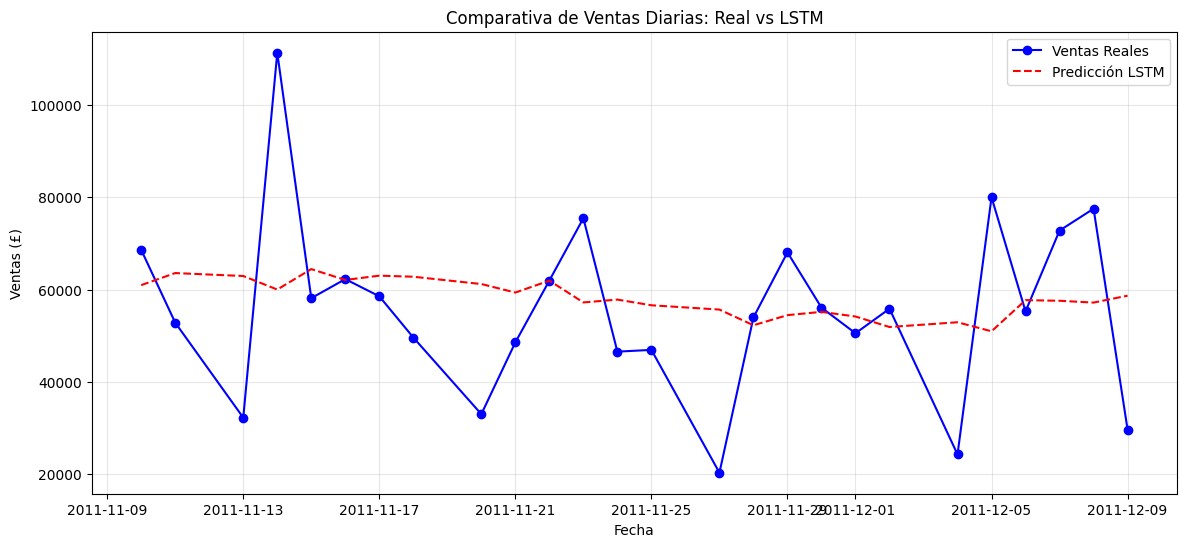

In [25]:
# --- IMPORTACIONES NECESARIAS ---
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 7. Arquitectura del Modelo LSTM
model = Sequential()
model.add(LSTM(32, input_shape=(LOOKBACK, 1)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

# 8. Entrenamiento
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False, # Importante para series temporales
    verbose=1
)

print(f"\n Tiempo de entrenamiento: {time.time() - start_time:.2f} segundos")

# 9. Predicciones en la misma escala (0 a 1)
preds_scaled = model.predict(X_test)

# 10. INVERSIÓN DE LA ESCALA (El paso clave)
# a) Invertir MinMaxScaler
preds_unscaled_log = scaler.inverse_transform(preds_scaled)
y_test_unscaled_log = scaler.inverse_transform(y_test.reshape(-1, 1))

# b) Invertir Logaritmo (expm1 deshace log1p)
preds_real = np.expm1(preds_unscaled_log).flatten()
y_real = np.expm1(y_test_unscaled_log).flatten()

# 11. FECHAS ALINEADAS PARA EL TEST
dates_test = df_test['date'].iloc[idx_test].values

# -----------------------------------------------------------
# COMPARATIVA DE MÉTRICAS (CON Y SIN ANOMALÍA)
# -----------------------------------------------------------

# 1. Calcular métricas CON el día anómalo (Pedido mayorista incluido)
mae_con = mean_absolute_error(y_real, preds_real)
rmse_con = np.sqrt(mean_squared_error(y_real, preds_real))
r2_con = r2_score(y_real, preds_real)

# 2. Identificar y aislar el día 14-11-2011
fecha_anomala = pd.to_datetime('2011-11-14').date()

# Aseguramos que dates_test esté en formato date para hacer la comparación
dates_test_date = np.array([pd.to_datetime(d).date() for d in dates_test])

# Creamos una máscara booleana: True para todos los días EXCEPTO el 14-11
mascara_sin_anomalia = dates_test_date != fecha_anomala

# Filtramos las predicciones y los valores reales usando la máscara
y_real_sin = y_real[mascara_sin_anomalia]
preds_real_sin = preds_real[mascara_sin_anomalia]

# 3. Calcular métricas SIN el día anómalo
mae_sin = mean_absolute_error(y_real_sin, preds_real_sin)
rmse_sin = np.sqrt(mean_squared_error(y_real_sin, preds_real_sin))
r2_sin = r2_score(y_real_sin, preds_real_sin)

# 4. Imprimir la tabla comparativa
print("="*60)
print("       COMPARATIVA DE MÉTRICAS (Efecto del Outlier)       ")
print("="*60)
print(f"{'Métrica':<10} | {'CON día 14-11':<20} | {'SIN día 14-11':<20}")
print("-" * 60)
print(f"{'MAE':<10} | £ {mae_con:<18,.2f} | £ {mae_sin:<18,.2f}")
print(f"{'RMSE':<10} | £ {rmse_con:<18,.2f} | £ {rmse_sin:<18,.2f}")
print(f"{'R2':<10} |   {r2_con:<18.4f} |   {r2_sin:<18.4f}")
print("="*60)

# Verificación de cuántos días se evaluaron en cada caso
print(f"\n[Info] Días evaluados CON anomalía: {len(y_real)}")
print(f"[Info] Días evaluados SIN anomalía: {len(y_real_sin)}")

# 13. Visualización
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_real, label="Ventas Reales", color='blue', marker='o')
plt.plot(dates_test, preds_real, label="Predicción LSTM", color='red', linestyle='--')
plt.title("Comparativa de Ventas Diarias: Real vs LSTM")
plt.xlabel("Fecha")
plt.ylabel("Ventas (£)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# 14. Preparar DataFrame para exportación
df_eval_corregido = pd.DataFrame({
    'Fecha': dates_test,
    'Ventas_Reales': y_real,
    'Prediccion_LSTM': preds_real
})

print("\n--- EXPORTANDO RESULTADOS ---")
ruta_drive = '/content/drive/MyDrive/TFM_Prediccion_Ventas_LSTM_Corregido.csv'

try:
    df_eval_corregido.to_csv(ruta_drive, index=False)
    print(f"Archivo exportado correctamente en:\n{ruta_drive}")
except Exception as e:
    print(f"Error al exportar: {e}\n(Si no estás en Drive, cambia la ruta a local)")


--- EXPORTANDO RESULTADOS ---
Archivo exportado correctamente en:
/content/drive/MyDrive/TFM_Prediccion_Ventas_LSTM_Corregido.csv
